# 🤖 Trenowanie Modeli - Moodify

## 🎯 Cel
Wytrenowanie dwóch prostych modeli do rozpoznawania emocji:
- 📝 **Model Tekstowy** - scikit-learn (TF-IDF + klasyfikator)
- 📸 **Model Obrazowy** - TensorFlow/Keras (Transfer Learning)

---
# CZĘŚĆ 1: MODEL TEKSTOWY (scikit-learn)
---

## 1. Instalacja bibliotek

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn

## 2. Import bibliotek

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

## 3. Wczytanie danych tekstowych

In [3]:
train_text = pd.read_csv('processed_data/train_text.csv')
val_text = pd.read_csv('processed_data/val_text.csv')
test_text = pd.read_csv('processed_data/test_text.csv')

print(f"Train: {len(train_text)}, Val: {len(val_text)}, Test: {len(test_text)}")
train_text.head()

Train: 16000, Val: 2000, Test: 2000


,text,emotion
0,i didnt feel humiliated,Smutek
1,i can go from feeling so hopeless to so damned...,Smutek
2,im grabbing a minute to post i feel greedy wrong,Złość
3,i am ever feeling nostalgic about the fireplac...,Szczęście
4,i am feeling grouchy,Złość


## 4. TF-IDF Vectorization

**Parametry:**
- max_features=5000: Top 5000 słów
- min_df=2: Słowo w min 2 dokumentach
- max_df=0.8: Ignoruj słowa w >80% dokumentów
- ngram_range=(1,2): Pojedyncze słowa i pary

In [4]:
vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8, ngram_range=(1, 2))

X_train = vectorizer.fit_transform(train_text['text'])
y_train = train_text['emotion']

X_val = vectorizer.transform(val_text['text'])
y_val = val_text['emotion']

X_test = vectorizer.transform(test_text['text'])
y_test = test_text['emotion']

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"Słownik: {len(vectorizer.vocabulary_)} słów")

X_train: (16000, 5000), X_val: (2000, 5000), X_test: (2000, 5000)
Słownik: 5000 słów


## 5. Trening modelu SVM

In [5]:
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

val_accuracy = svm.score(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy:.2%}")

Validation Accuracy: 90.80%


## 6. Ewaluacja na zbiorze testowym

In [6]:
y_pred = svm.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)

print(f"Test Accuracy: {report['accuracy']:.2%}\n")
for emotion, metrics in report.items():
    if emotion not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"{emotion}: Precision={metrics['precision']:.2%}, Recall={metrics['recall']:.2%}, F1={metrics['f1-score']:.2%}")

Test Accuracy: 90.10%

Smutek: Precision=92.01%, Recall=91.22%, F1=91.62%
Strach: Precision=84.91%, Recall=80.36%, F1=82.57%
Szczęście: Precision=91.72%, Recall=97.31%, F1=94.43%
Zaskoczenie: Precision=70.00%, Recall=53.03%, F1=60.34%
Złość: Precision=88.28%, Recall=82.18%, F1=85.12%


## 7. Confusion Matrix

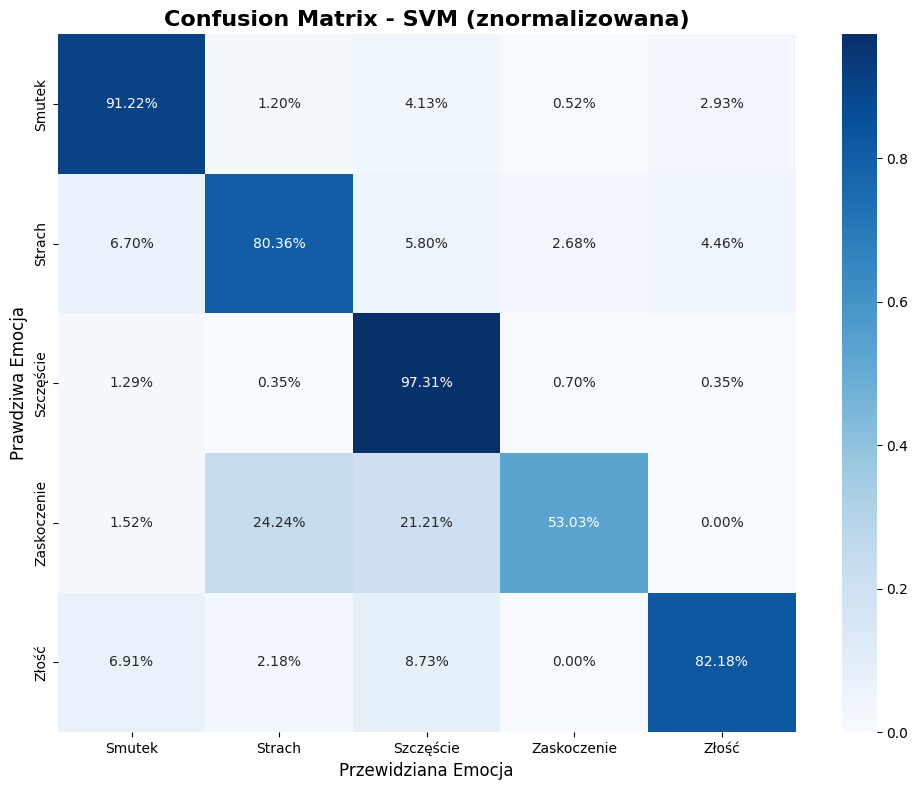

In [7]:
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
emotions = sorted(train_text['emotion'].unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=emotions,
            yticklabels=emotions)
plt.title('Confusion Matrix - SVM (znormalizowana)', fontsize=16, fontweight='bold')
plt.ylabel('Prawdziwa Emocja', fontsize=12)
plt.xlabel('Przewidziana Emocja', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Zapisanie modelu tekstowego

In [8]:
import os

os.makedirs('saved_models', exist_ok=True)
joblib.dump(svm, 'saved_models/svm_text_model.pkl')
joblib.dump(vectorizer, 'saved_models/tfidf_vectorizer.pkl')

print("✅ Model zapisany")

✅ Model zapisany


## 9. Test predykcji na nowych tekstach

In [9]:
def predict_emotion_text(text):
    return svm.predict(vectorizer.transform([text]))[0]

test_texts = [
    "I am so happy today!",
    "This is terrible, I hate it",
    "I'm feeling really sad and lonely",
    "Wow, I didn't expect that!",
    "I'm scared of what might happen"
]

for text in test_texts:
    print(f'"{text}" → {predict_emotion_text(text)}')

"I am so happy today!" → Szczęście
"This is terrible, I hate it" → Smutek
"I'm feeling really sad and lonely" → Smutek
"Wow, I didn't expect that!" → Szczęście
"I'm scared of what might happen" → Strach


---
# CZĘŚĆ 2: MODEL OBRAZOWY (TensorFlow/Keras)
---

## 10. Instalacja bibliotek

## 11. Import bibliotek TensorFlow

In [10]:
!pip install tensorflow[and-cuda] pillow keras-tuner

## 12. Konfiguracja CUDA

⚠️ Wykonać PRZED importem TensorFlow!

In [11]:
import os
import sys
from pathlib import Path
import ctypes

site_packages = None
for path in sys.path:
    if 'site-packages' in path:
        site_packages = Path(path)
        break

if site_packages:
    nvidia_libs_dirs = [
        site_packages / 'nvidia' / 'cuda_runtime' / 'lib',
        site_packages / 'nvidia' / 'cudnn' / 'lib', 
        site_packages / 'nvidia' / 'cublas' / 'lib',
        site_packages / 'nvidia' / 'cufft' / 'lib',
        site_packages / 'nvidia' / 'curand' / 'lib',
        site_packages / 'nvidia' / 'cusolver' / 'lib',
        site_packages / 'nvidia' / 'cusparse' / 'lib',
        site_packages / 'nvidia' / 'nvjitlink' / 'lib',
    ]
    
    new_paths = [str(p) for p in nvidia_libs_dirs if p.exists()]
    if new_paths:
        os.environ['LD_LIBRARY_PATH'] = ':'.join(new_paths) + (':' + os.environ.get('LD_LIBRARY_PATH', ''))
        for lib_dir in nvidia_libs_dirs:
            if lib_dir.exists():
                for so_file in lib_dir.glob('*.so*'):
                    if so_file.is_file() and not so_file.is_symlink():
                        try:
                            ctypes.CDLL(str(so_file), mode=ctypes.RTLD_GLOBAL)
                            break
                        except:
                            pass

print("✅ CUDA skonfigurowane")

✅ CUDA skonfigurowane


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from PIL import Image

print(f"TensorFlow {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

2025-11-26 21:17:27.917784: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.20.0
GPU: True


## 13. Konfiguracja GPU

In [13]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU: {len(gpus)} urządzeń")
else:
    print("⚠️ Brak GPU - trening na CPU")

✅ GPU: 1 urządzeń


## 14. Wczytanie danych obrazowych

In [14]:
train_img = pd.read_csv('processed_data/train_images.csv')
val_img = pd.read_csv('processed_data/val_images.csv')
test_img = pd.read_csv('processed_data/test_images.csv')

train_img = train_img[train_img['emotion'] != 'neutral'].reset_index(drop=True)
val_img = val_img[val_img['emotion'] != 'neutral'].reset_index(drop=True)
test_img = test_img[test_img['emotion'] != 'neutral'].reset_index(drop=True)

emotions_list = sorted(train_img['emotion'].unique())
emotion_to_id = {emotion: idx for idx, emotion in enumerate(emotions_list)}
id_to_emotion = {idx: emotion for emotion, idx in emotion_to_id.items()}

print(f"Train: {len(train_img)}, Val: {len(val_img)}, Test: {len(test_img)}")
print(f"Emocje: {emotions_list}")

Train: 14106, Val: 3023, Test: 3023
Emocje: ['Smutek', 'Strach', 'Szczęście', 'Zaskoczenie', 'Złość']


## 15. Wczytanie ścieżki bazowej

In [15]:
import json

with open('processed_data/data_paths.json', 'r') as f:
    data_paths = json.load(f)

BASE_PATH = data_paths['affectnet_base_path']
print(f"Ścieżka bazowa: {BASE_PATH}")

Ścieżka bazowa: /home/dupa/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1


## 16. Generator danych

**Data augmentation:** flip, brightness, contrast, saturation, rotation, zoom, crop  
**Normalizacja:** [0, 1]  
**Labels:** one-hot encoding

In [16]:
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5

def create_dataset(df, emotion_to_id, base_path, augment=False):
    def load_image(path, label):
        full_path = tf.strings.join([base_path, os.sep, path])
        img = tf.io.read_file(full_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        return img / 255.0, label
    
    def augment_image(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
        
        if tf.random.uniform([]) > 0.5:
            k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
            img = tf.image.rot90(img, k=k % 4)
        
        zoom_factor = tf.random.uniform([], minval=0.9, maxval=1.1)
        new_size = tf.cast(IMG_SIZE * zoom_factor, tf.int32)
        img = tf.image.resize(img, [new_size, new_size])
        img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE, IMG_SIZE)
        img = tf.image.random_crop(img, size=[IMG_SIZE, IMG_SIZE, 3])
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        return tf.clip_by_value(img, 0.0, 1.0), label
    
    labels = to_categorical(df['emotion'].map(emotion_to_id).values, num_classes=NUM_CLASSES)
    dataset = tf.data.Dataset.from_tensor_slices((df['path'].values, labels))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.shuffle(1000)
    
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_img, emotion_to_id, BASE_PATH, augment=True)
val_ds = create_dataset(val_img, emotion_to_id, BASE_PATH, augment=False)
test_ds = create_dataset(test_img, emotion_to_id, BASE_PATH, augment=False)

print("✅ Datasety gotowe")

I0000 00:00:1764188249.985900    5114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4294 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:09:00.0, compute capability: 7.5


✅ Datasety gotowe


## 17. Hyperparameter Tuning - Hyperband

**Cel:** val_accuracy ~75%+

**Analiza poprzednich wyników:**
- learning_rate=0.001 lub 0.0003 (najlepsze wyniki: 57%)
- units_2=192 (najczęściej w TOP 10)
- dropout_2=0.4 lub 0.3
- Poprzednio brak fine-tuningu CNN blokował accuracy

**Nowa strategia:**
- Fine-tuning ostatnich 20 warstw MobileNetV2 (cel: +15-20% accuracy)
- 8 kombinacji (mniej niż poprzednio, bo fine-tuning 2x wolniejszy)
- Max 45 min tunowania

In [17]:
import keras_tuner as kt
from tensorflow.keras import regularizers
import datetime

def build_tuned_model(hp):
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    
    unfreeze_layers = 20
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False
    
    units_1 = hp.Choice('units_1', values=[256])
    units_2 = hp.Choice('units_2', values=[192])
    dropout_1 = hp.Choice('dropout_1', values=[0.3, 0.5])
    dropout_2 = hp.Choice('dropout_2', values=[0.3, 0.4])
    learning_rate = hp.Choice('learning_rate', values=[0.0003, 0.001])
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(units_1, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
        BatchNormalization(),
        Dropout(dropout_1),
        Dense(units_2, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
        BatchNormalization(),
        Dropout(dropout_2),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

log_dir = "keras_tuner/tensorboard_logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq='epoch', profile_batch=0)

print(f"TensorBoard: tensorboard --logdir keras_tuner/tensorboard_logs")

tuner = kt.Hyperband(
    build_tuned_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    hyperband_iterations=1,
    directory='keras_tuner',
    project_name='moodify_hyperband_finetuned',
    overwrite=True,
    seed=42
)

early_stop_tuning = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)
reduce_lr_tuning = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

print("Rozpoczynam tunowanie z fine-tuningiem CNN (max 45 min)...")
print(f"Strategia: max_epochs=10, factor=3, 8 kombinacji")
print(f"Fine-tuning: ostatnie 20 warstw MobileNetV2")
print(f"Oczekiwany czas: ~40-45 min (~10-12 modeli, ~4 min/model)")
print(f"Oczekiwany wynik: 70-75% (vs poprzednie 57%)")

tuner.search(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop_tuning, reduce_lr_tuning, tensorboard_callback], verbose=2)

best_models = tuner.get_best_hyperparameters(num_trials=3)
best_hps = best_models[0]

print("\nNajlepszy model:")
print(f"units_1={best_hps.get('units_1')}, units_2={best_hps.get('units_2')}")
print(f"dropout_1={best_hps.get('dropout_1'):.2f}, dropout_2={best_hps.get('dropout_2'):.2f}")
print(f"learning_rate={best_hps.get('learning_rate'):.6f}")
print(f"Fine-tuning: 20 ostatnich warstw MobileNetV2")

Trial 8 Complete [00h 01m 04s]
val_accuracy: 0.4353291392326355

Best val_accuracy So Far: 0.5894806385040283
Total elapsed time: 00h 09m 41s

Najlepszy model:
units_1=256, units_2=192
dropout_1=0.30, dropout_2=0.30
learning_rate=0.001000
Fine-tuning: 20 ostatnich warstw MobileNetV2


### Funkcja budująca model

**Fine-tuning:** Ostatnie 20 warstw MobileNetV2 odmrożone  
**Parametry do tunowania:**
- units_1: 256 (stałe - najlepsze z poprzednich)
- units_2: 192 (stałe - najlepsze)
- dropout_1: 0.3 lub 0.5
- dropout_2: 0.3 lub 0.4
- learning_rate: 0.0003 lub 0.001

**Kombinacji:** 8 (1×1×2×2×2)

In [18]:
model_image = tuner.hypermodel.build(best_hps)
model_image.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 192)            │        49,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           965 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,638,021 (10.06 MB)

 Trainable params: 1,585,221 (6.05 MB)

 Non-trainable params: 1,052,800 (4.02 MB)

## 18. Trening finalnego modelu

**Cel:** val_accuracy ~75%+  
**Czas:** max 45 min  
**Epoki:** 50 z early stopping (patience=5)  
**Strategia:** Fine-tuning CNN + długi trening (50 epok = ~40 min z fine-tuningiem)

In [19]:
checkpoint = keras.callbacks.ModelCheckpoint('saved_models/image_model_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

print("Rozpoczynam finalne trenowanie (max 45 min)...")
print("Czas: ~0.8 min/epoka, max 50 epok = ~40 min")

history = model_image.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[checkpoint, early_stop, reduce_lr])

print(f"Najlepsza val_accuracy: {max(history.history['val_accuracy']):.2%}")
print(f"Wytrenowano w {len(history.history['accuracy'])} epokach")

Rozpoczynam finalne trenowanie (max 45 min)...
Czas: ~0.8 min/epoka, max 50 epok = ~40 min
Epoch 1/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4210 - loss: 1.6205
Epoch 1: val_accuracy improved from None to 0.32650, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 39s 66ms/step - accuracy: 0.4826 - loss: 1.3679 - val_accuracy: 0.3265 - val_loss: 2.7458 - learning_rate: 0.0010
Epoch 2/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5584 - loss: 1.1018
Epoch 2: val_accuracy improved from 0.32650 to 0.53688, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.5715 - loss: 1.0753 - val_accuracy: 0.5369 - val_loss: 1.3863 - learning_rate: 0.0010
Epoch 3/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5999 - loss: 1.0121
Epoch 3: val_accuracy improved from 0.53688 to 0.58551, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.6110 - loss: 0.9875 - val_accuracy: 0.5855 - val_loss: 1.4132 - learning_rate: 0.0010
Epoch 4/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6299 - loss: 0.9658
Epoch 4: val_accuracy did not improve from 0.58551

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.6349 - loss: 0.9475 - val_accuracy: 0.4922 - val_loss: 1.7116 - learning_rate: 0.0010
Epoch 5/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6590 - loss: 0.8819
Epoch 5: val_accuracy improved from 0.58551 to 0.60304, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.6686 - loss: 0.8599 - val_accuracy: 0.6030 - val_loss: 1.1365 - learning_rate: 5.0000e-04
Epoch 6/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6757 - loss: 0.8519
Epoch 6: val_accuracy improved from 0.60304 to 0.61065, saving model to saved_models/image_model_best.h5


...

441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.7497 - loss: 0.6694 - val_accuracy: 0.6977 - val_loss: 0.8293 - learning_rate: 2.5000e-04
Epoch 13/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7429 - loss: 0.6658
Epoch 13: val_accuracy did not improve from 0.69765
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.7510 - loss: 0.6495 - val_accuracy: 0.6718 - val_loss: 0.9536 - learning_rate: 2.5000e-04
Epoch 14/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7582 - loss: 0.6436
Epoch 14: val_accuracy did not improve from 0.69765

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.7644 - loss: 0.6365 - val_accuracy: 0.6811 - val_loss: 0.9318 - learning_rate: 2.5000e-04
Epoch 15/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7789 - loss: 0.6114
Epoch 15: val_accuracy did not improve from 0.69765
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.7871

441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.8022 - loss: 0.5350 - val_accuracy: 0.6983 - val_loss: 0.9195 - learning_rate: 6.2500e-05
Epoch 18/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8061 - loss: 0.5355
Epoch 18: val_accuracy did not improve from 0.69831

Epoch 18: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8116 - loss: 0.5237 - val_accuracy: 0.6977 - val_loss: 0.9051 - learning_rate: 6.2500e-05
Epoch 19/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8145 - loss: 0.5207
Epoch 19: val_accuracy improved from 0.69831 to 0.70559, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.8231 - loss: 0.5001 - val_accuracy: 0.7056 - val_loss: 0.9182 - learning_rate: 3.1250e-05
Epoch 20/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8150 - loss: 0.5110
Epoch 20: val_accuracy did not improve from 0.70559

Epoch 20: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8221 - loss: 0.4922 - val_accuracy: 0.7043 - val_loss: 0.8971 - learning_rate: 3.1250e-05
Epoch 21/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8157 - loss: 0.5037
Epoch 21: val_accuracy improved from 0.70559 to 0.70658, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.8231 - loss: 0.4908 - val_accuracy: 0.7066 - val_loss: 0.8916 - learning_rate: 1.5625e-05
Epoch 22/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8174 - loss: 0.5093
Epoch 22: val_accuracy did not improve from 0.70658

Epoch 22: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8220 - loss: 0.4942 - val_accuracy: 0.7066 - val_loss: 0.8862 - learning_rate: 1.5625e-05
Epoch 23/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8201 - loss: 0.4945
Epoch 23: val_accuracy improved from 0.70658 to 0.70791, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8292 - loss: 0.4773 - val_accuracy: 0.7079 - val_loss: 0.8874 - learning_rate: 7.8125e-06
Epoch 24/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8203 - loss: 0.4888
Epoch 24: val_accuracy did not improve from 0.70791

Epoch 24: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8294 - loss: 0.4718 - val_accuracy: 0.7066 - val_loss: 0.8860 - learning_rate: 7.8125e-06
Epoch 25/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8252 - loss: 0.4909
Epoch 25: val_accuracy did not improve from 0.70791
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8312 - loss: 0.4790 - val_accuracy: 0.7046 - val_loss: 0.8912 - learning_rate: 3.9063e-06
Epoch 26/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8283 - loss: 0.4960
Epoch 26: val_accuracy did not improve from 0.70791

Epoch 26: ReduceLROnPlateau reducing learning rate to 1.9531

## 19. Wykresy treningu

In [20]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
difference = final_train_acc - final_val_acc

print(f"Train: {final_train_acc:.2%}, Val: {final_val_acc:.2%}, Różnica: {difference:.2%}")

if difference < 0.05:
    print("🟢 GOOD FIT")
elif difference < 0.10:
    print("🟡 SLIGHT OVERFITTING")
else:
    print("🔴 OVERFITTING")

Train: 82.82%, Val: 70.46%, Różnica: 12.36%
🔴 OVERFITTING


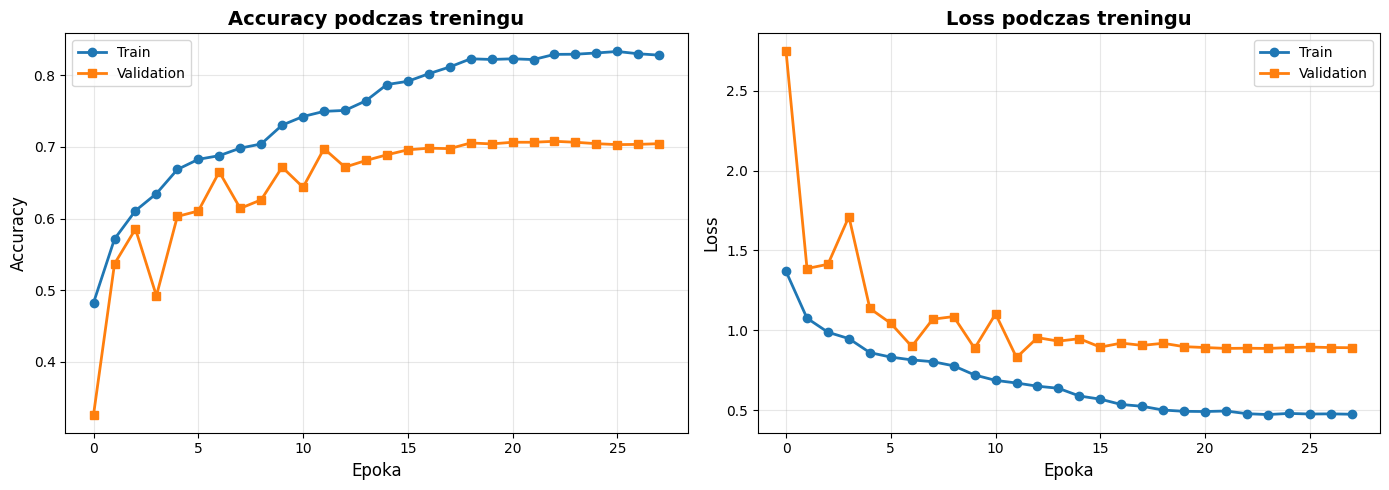

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], marker='o', label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], marker='s', label='Validation', linewidth=2)
ax1.set_title('Accuracy podczas treningu', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoka', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], marker='o', label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], marker='s', label='Validation', linewidth=2)
ax2.set_title('Loss podczas treningu', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoka', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 20. Ewaluacja na zbiorze testowym

In [22]:
model_image = keras.models.load_model('saved_models/image_model_best.h5')
test_loss, test_acc = model_image.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.2%}")

95/95 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.7307 - loss: 0.8516
95/95 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.7307 - loss: 0.8516
Test Accuracy: 73.07%
Test Accuracy: 73.07%


## 21. Confusion Matrix

2025-11-26 21:36:59.960954: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


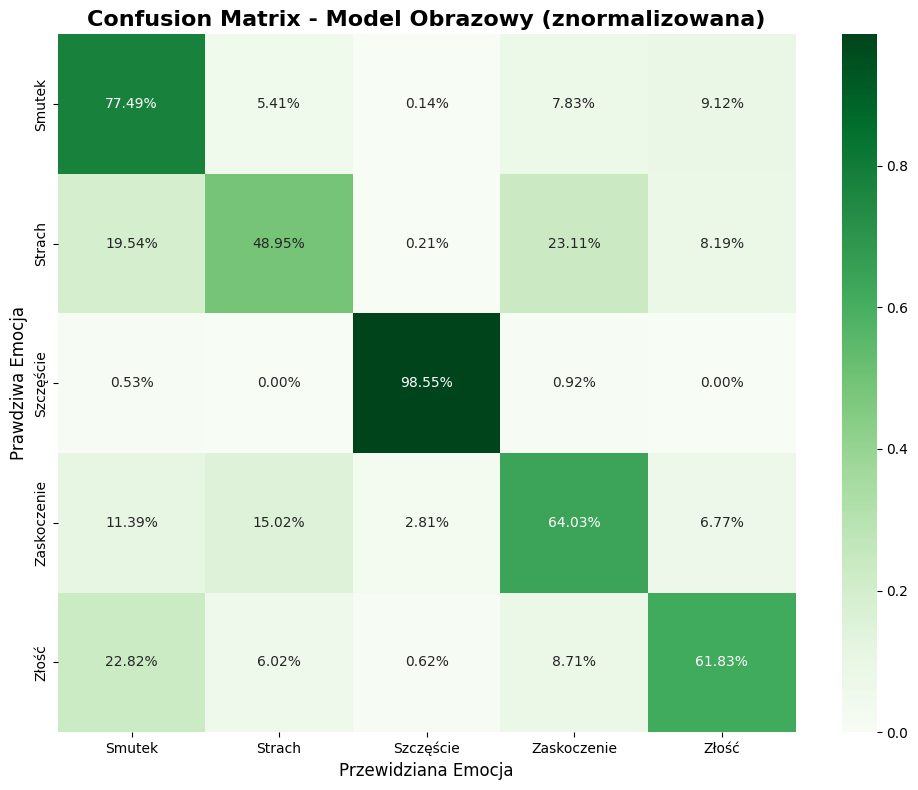

Smutek: Precision=66.34%, Recall=77.49%, F1=71.48%
Strach: Precision=59.59%, Recall=48.95%, F1=53.75%
Szczęście: Precision=97.14%, Recall=98.55%, F1=97.84%
Zaskoczenie: Precision=64.45%, Recall=64.03%, F1=64.24%
Złość: Precision=67.42%, Recall=61.83%, F1=64.50%

Accuracy: 73.07%


In [23]:
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model_image.predict(images, verbose=0)
    y_pred.extend(preds.argmax(axis=1))
    y_true.extend(labels.numpy().argmax(axis=1))

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', xticklabels=emotions_list, yticklabels=emotions_list)
plt.title('Confusion Matrix - Model Obrazowy (znormalizowana)', fontsize=16, fontweight='bold')
plt.ylabel('Prawdziwa Emocja', fontsize=12)
plt.xlabel('Przewidziana Emocja', fontsize=12)
plt.tight_layout()
plt.show()

report = classification_report(y_true, y_pred, target_names=emotions_list, output_dict=True)
for emotion in emotions_list:
    m = report[emotion]
    print(f"{emotion}: Precision={m['precision']:.2%}, Recall={m['recall']:.2%}, F1={m['f1-score']:.2%}")
print(f"\nAccuracy: {report['accuracy']:.2%}")

## 22. Zapisanie finalnego modelu

In [24]:
import json

model_image.save('saved_models/image_model_final.h5')
with open('saved_models/image_emotion_map.json', 'w') as f:
    json.dump(id_to_emotion, f)

print("✅ Model zapisany")

✅ Model zapisany
